In [191]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style("whitegrid")
df_stock=pd.read_csv("stock_dataset_dirty.csv")
df_stock


,Date,Symbol,Open,High,Low,Close,Volume,Market_Cap,Sector,Profit_Margin
0,2023-01-01,AMZN,472.847313,395.110972,123.867217,312.916750,428910,2.563560,Retail,13.505575
1,2023-01-02,TSLA,326.053273,134.194156,340.825590,141.306004,969485,1.968346,Finance,26.398130
2,2023-01-03,GOOGL,378.660330,133.858975,482.565246,169.009551,255063,2.588029,Energy,15.866954
3,2023-01-04,TSLA,468.999752,109.903932,170.092522,327.189719,887733,2.152978,Tech,9.820990
4,2023-01-05,TSLA,382.895454,492.383066,408.075071,218.543045,783970,1.684139,Tech,9.777641
...,...,...,...,...,...,...,...,...,...,...
1015,2023-01-16,MSFT,435.559235,414.570928,348.042998,283.171598,745972,2.142398,Tech,8.734985
1016,2023-01-17,AMZN,149.865072,212.343803,358.307189,190.608650,947324,2.726863,Retail,17.749627
1017,2023-01-18,TSLA,468.336753,113.482709,159.266399,345.588123,135525,1.278900,Energy,16.514564
1018,2023-01-19,AAPL,447.958545,138.279525,318.208698,201.143247,106464,2.138413,Tech,27.519004


In [192]:
df_stock.head()
df_stock.shape

(1020, 10)

In [193]:
df_stock.info()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           1020 non-null   str    
 1   Symbol         1020 non-null   str    
 2   Open           1000 non-null   float64
 3   High           1000 non-null   float64
 4   Low            1020 non-null   float64
 5   Close          1020 non-null   float64
 6   Volume         1020 non-null   int64  
 7   Market_Cap     1020 non-null   float64
 8   Sector         1020 non-null   str    
 9   Profit_Margin  1020 non-null   float64
dtypes: float64(6), int64(1), str(3)
memory usage: 79.8 KB


In [194]:
df_stock["Date"]=pd.to_datetime(df_stock["Date"])

In [195]:
df_stock.info()

<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           1020 non-null   datetime64[us]
 1   Symbol         1020 non-null   str           
 2   Open           1000 non-null   float64       
 3   High           1000 non-null   float64       
 4   Low            1020 non-null   float64       
 5   Close          1020 non-null   float64       
 6   Volume         1020 non-null   int64         
 7   Market_Cap     1020 non-null   float64       
 8   Sector         1020 non-null   str           
 9   Profit_Margin  1020 non-null   float64       
dtypes: datetime64[us](1), float64(6), int64(1), str(2)
memory usage: 79.8 KB


In [196]:
df_stock.isnull().sum()

Date              0
Symbol            0
Open             20
High             20
Low               0
Close             0
Volume            0
Market_Cap        0
Sector            0
Profit_Margin     0
dtype: int64

In [197]:
num_cols=["Open","High","Low","Close","Volume","Market_Cap","Profit_Margin"]
for col in num_cols:
    df_stock[col]=df_stock[col].fillna(df_stock[col].mean())

In [198]:
df_stock.isnull().sum()

Date             0
Symbol           0
Open             0
High             0
Low              0
Close            0
Volume           0
Market_Cap       0
Sector           0
Profit_Margin    0
dtype: int64

In [199]:
df_stock.duplicated().sum()
df_stock=df_stock.drop_duplicates()
df_stock.duplicated().sum()

np.int64(0)

In [200]:
df_stock["Year"]=df_stock["Date"].dt.year
df_stock["Month"]=df_stock["Date"].dt.month
df_stock["Day"]=df_stock["Date"].dt.day
df_stock["Day_Name"]=df_stock["Date"].dt.day_name()

In [201]:
df_stock

,Date,Symbol,Open,High,Low,Close,Volume,Market_Cap,Sector,Profit_Margin,Year,Month,Day,Day_Name
0,2023-01-01,AMZN,472.847313,395.110972,123.867217,312.916750,428910,2.563560,Retail,13.505575,2023,1,1,Sunday
1,2023-01-02,TSLA,326.053273,134.194156,340.825590,141.306004,969485,1.968346,Finance,26.398130,2023,1,2,Monday
2,2023-01-03,GOOGL,378.660330,133.858975,482.565246,169.009551,255063,2.588029,Energy,15.866954,2023,1,3,Tuesday
3,2023-01-04,TSLA,468.999752,109.903932,170.092522,327.189719,887733,2.152978,Tech,9.820990,2023,1,4,Wednesday
4,2023-01-05,TSLA,382.895454,492.383066,408.075071,218.543045,783970,1.684139,Tech,9.777641,2023,1,5,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,2025-09-22,MSFT,394.973507,502.363211,121.557501,481.361152,324866,2.007439,Tech,13.946029,2025,9,22,Monday
996,2025-09-23,AAPL,304.888768,335.663611,329.964715,124.090778,250862,2.660406,Tech,5.211287,2025,9,23,Tuesday
997,2025-09-24,AAPL,372.091112,210.114422,386.852337,219.060111,682943,2.328024,Energy,25.980199,2025,9,24,Wednesday
998,2025-09-25,AMZN,116.669160,281.983334,107.815161,219.226480,815003,1.676736,Tech,5.799862,2025,9,25,Thursday


In [202]:
group_symbol=df_stock.groupby("Symbol")["Close"].mean()
print(group_symbol)

Symbol
AAPL     297.685663
AMZN     292.600684
GOOGL    292.723883
MSFT     295.416597
TSLA     303.411533
Name: Close, dtype: float64


In [203]:
sector_profit=df_stock.groupby("Sector")["Profit_Margin"].mean()
print(sector_profit)

Sector
Energy     17.810481
Finance    17.084998
Retail     17.169298
Tech       16.303860
Name: Profit_Margin, dtype: float64


In [204]:
volume_symbol = df_stock.groupby("Symbol")["Volume"].sum()

print(volume_symbol)

Symbol
AAPL     109961827
AMZN     116972473
GOOGL    106568815
MSFT     100428282
TSLA     111994190
Name: Volume, dtype: int64


In [205]:
pivot_table=pd.pivot_table(df_stock,values="Close",index="Symbol",columns="Sector",aggfunc="mean")
print(pivot_table)

Sector      Energy     Finance      Retail        Tech
Symbol                                                
AAPL    320.384623  306.587006  289.615904  267.600190
AMZN    287.534278  309.302526  289.908609  282.533901
GOOGL   286.112448  310.681863  275.062856  292.494696
MSFT    309.948386  287.196520  295.909609  293.125352
TSLA    304.923643  261.188151  308.744659  327.213132


In [206]:
pivot_table=pd.pivot_table(df_stock,values="Close",index="Symbol",columns="Sector",aggfunc="sum")
print(pivot_table)

Sector        Energy       Finance        Retail          Tech
Symbol                                                        
AAPL    17941.538882  17782.046354  14480.795218  12309.608733
AMZN    13226.576809  16702.336379  15655.064886  14691.762864
GOOGL   13161.172600  16776.820611  10177.325682  15502.218868
MSFT    11778.038684  16083.005128  13611.842001  14656.267579
TSLA    15856.029445  10969.902339  15437.232937  19632.787940


In [207]:
df_stock.groupby("Symbol")["Volume"].sum().sort_values(ascending=False)

Symbol
AMZN     116972473
TSLA     111994190
AAPL     109961827
GOOGL    106568815
MSFT     100428282
Name: Volume, dtype: int64

In [208]:
df_stock.groupby("Sector")["Market_Cap"].mean()

Sector
Energy     2.018276
Finance    1.998393
Retail     1.964363
Tech       1.981805
Name: Market_Cap, dtype: float64

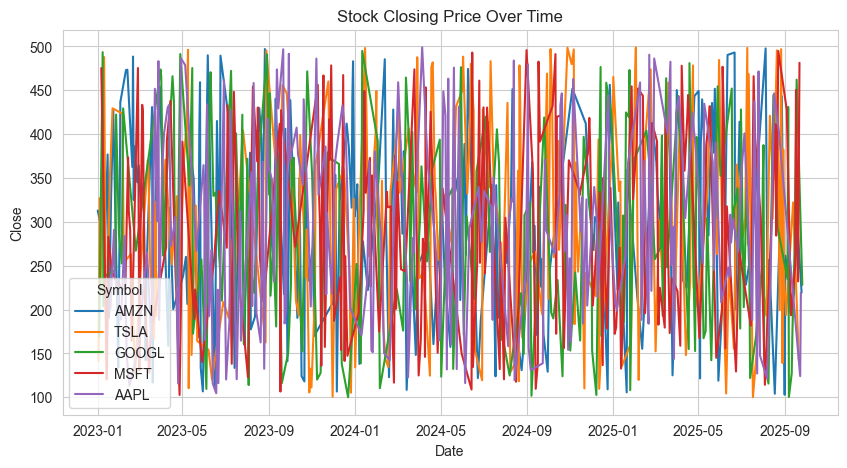

In [214]:
plt.figure(figsize=(10,5))
sns.lineplot(data=df_stock, x="Date", y="Close", hue="Symbol")
plt.title("Stock Closing Price Over Time")
plt.show()

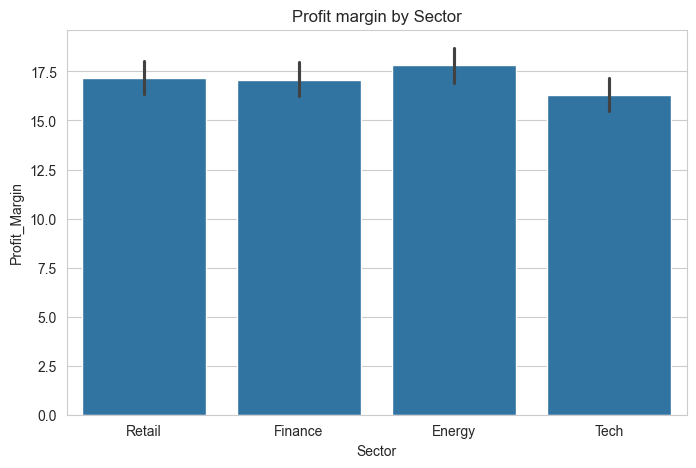

In [215]:
plt.figure(figsize=(8,5))
sns.barplot(data=df_stock,x="Sector",y="Profit_Margin")
plt.title("Profit margin by Sector")
plt.show()

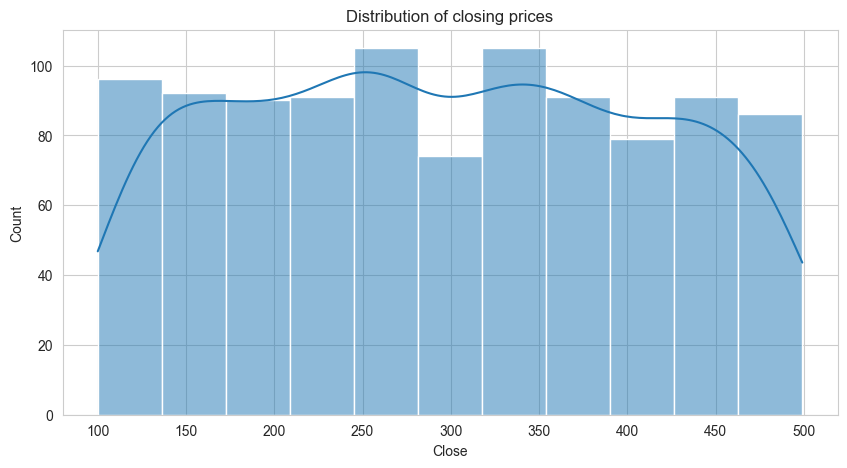

In [216]:
plt.figure(figsize=(10,5))
sns.histplot(df_stock["Close"],kde=True)
plt.title("Distribution of closing prices")
plt.show()

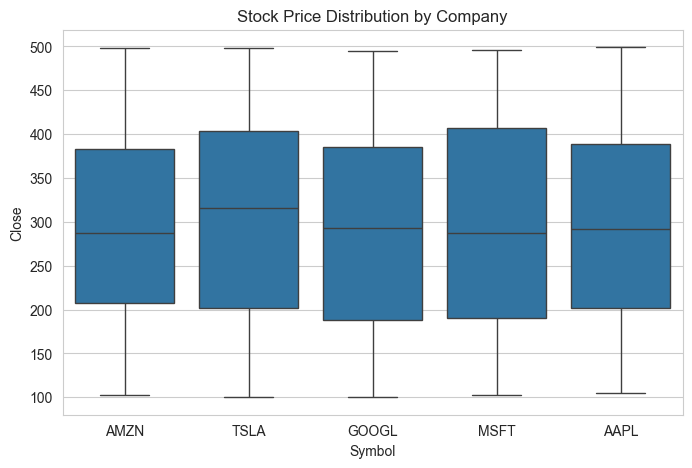

In [217]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_stock, x="Symbol", y="Close")
plt.title("Stock Price Distribution by Company")
plt.show()

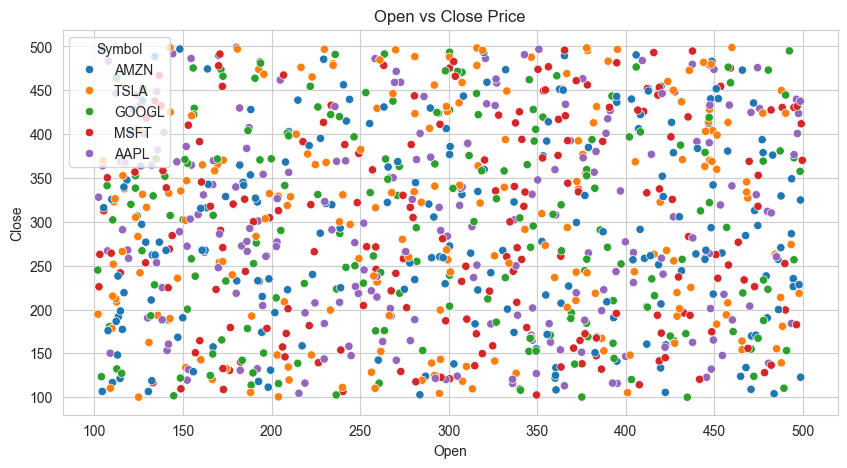

In [218]:
plt.figure(figsize=(10,5))
sns.scatterplot(data=df_stock,x="Open",y="Close",hue="Symbol")
plt.title("Open vs Close Price")
plt.show()

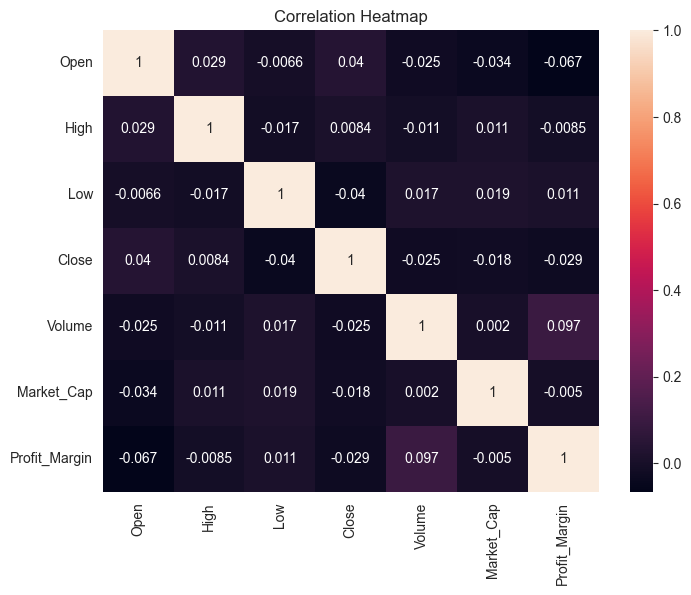

In [219]:
corr = df_stock[['Open','High','Low','Close','Volume','Market_Cap','Profit_Margin']].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True)
plt.title("Correlation Heatmap")
plt.show()